# Narrative Miners: Uncover the Stories That Drive Markets

## Automated Analysis of Market Narratives Across Multiple Document Sources

## Why It Matters

Understanding how market narratives emerge and evolve across different information sources is crucial for investment decision-making, but manually tracking narrative development across scattered news coverage, earnings calls, and regulatory filings is time consuming. Investment decisions need systematic analysis of narrative progression to identify emerging trends and timing patterns.

## What It Does

The `NarrativeMiner` class in the bigdata-research-tools package systematically tracks narrative evolution across multiple document types using unstructured data from news, transcripts, and filings. Built for analysts, portfolio managers, and investment professionals, it transforms scattered narrative signals into quantified trend intelligence and identifies timing patterns across different information sources.

## How It Works

The `NarrativeMiner` combines **multi-source content retrieval**, **temporal narrative tracking**, and **cross-source comparative analysis** to deliver:

- **Cross-document narrative mapping** across news media, earnings calls, and SEC filings
- **Temporal evolution tracking** showing how narratives develop and change over time across sources
- **Intensity measurement** quantifying narrative prevalence and significance across document types

## A Real-World Use Case

This cookbook demonstrates the complete workflow through analyzing "AI Bubble Concerns" narrative as it emerges and evolves across news, earnings calls, and regulatory filings, highlighting the difference between public discourse and corporate communications.

## Setup and Imports

## Async Compatibility Setup

**Run this cell first** - Required for Google Colab, Jupyter Notebooks, and VS Code with Jupyter extension:

### Why is this needed?

Interactive environments (Colab, Jupyter) already have an asyncio event loop running. When bigdata-research-tools makes async API calls (like to OpenAI), you'll get this error without nest_asyncio:

```
RuntimeError: asyncio.run() cannot be called from a running event loop
```

The `nest_asyncio.apply()` command patches this to allow nested event loops.

💡 **Tip**: If you're unsure which environment you're in, just run the cell below - it won't hurt in any environment!

In [2]:
import datetime
start = datetime.datetime.now()

try:
    import asyncio
    asyncio.get_running_loop()
    import nest_asyncio; nest_asyncio.apply()
    print("✅ nest_asyncio applied")
except (RuntimeError, ImportError):
    print("✅ nest_asyncio not needed or not available")

✅ nest_asyncio applied


## Environment Setup

The following cell configures the necessary path for the analysis

In [3]:
import os
import sys

current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.append(current_dir)
print(f"✅ Local environment setup complete")

✅ Local environment setup complete


## Import Required Libraries

Import the core libraries needed for narrative mining analysis, including the custom visualization and analysis tools.

In [4]:
from IPython.display import display, HTML, IFrame
import pandas as pd
from pandas import merge

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import warnings

from src.tool import (
    load_results, 
    extract_narrative_insights,
    create_source_summary,
    display_sample_data,
    visualize_cross_source_narratives, 
    visualize_news_narrative_breakdown
)

from bigdata_research_tools.workflows.narrative_miner import NarrativeMiner
from bigdata_research_tools.excel import ExcelManager
from bigdata_client import Bigdata
from bigdata_client.daterange import RollingDateRange
from bigdata_client.models.sources import Source
from bigdata_client.models.search import DocumentType

## Optional: Plotly Display Configuration

For better visualization rendering, you can also set the Plotly renderer:

In [5]:
import plotly
import plotly.graph_objects as go
import plotly.io as pio

# Try to detect the environment and set appropriate renderer
try:
    # Check if we're in JupyterLab
    import os
    if 'JUPYTERHUB_SERVICE_PREFIX' in os.environ or 'JPY_SESSION_NAME' in os.environ:
        pio.renderers.default = 'jupyterlab'
        print("✅ Plotly configured for JupyterLab")
    else:
        # Default for VS Code, Jupyter Notebook, etc.
        pio.renderers.default = 'plotly_mimetype+notebook'
        print("✅ Plotly configured for Jupyter/VS Code")
except:
    # Fallback to a more universal renderer
    pio.renderers.default = 'notebook'
    print("✅ Plotly configured with fallback renderer")



✅ Plotly configured for Jupyter/VS Code


/opt/anaconda/envs/pricing_power/lib/python3.11/site-packages/kaleido/__init__.py:14: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




## Define Output Paths

We define the output paths for our narrative mining results.

In [6]:
# Define output file paths for our results
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

news_results_path = f"{output_dir}/ai_bubble_news.xlsx"
transcripts_results_path = f"{output_dir}/ai_bubble_transcripts.xlsx"
filings_results_path = f"{output_dir}/ai_bubble_filings.xlsx"
visualization_path = f"{output_dir}/ai_bubble_narratives.html"

## Load Credentials

In [7]:
from dotenv import load_dotenv
from pathlib import Path

script_dir = Path(__file__).parent if '__file__' in globals() else Path.cwd()
load_dotenv(script_dir / '.env')

BIGDATA_USERNAME = os.getenv('BIGDATA_USERNAME')
BIGDATA_PASSWORD = os.getenv('BIGDATA_PASSWORD')
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')

if not all([BIGDATA_USERNAME, BIGDATA_PASSWORD, OPENAI_API_KEY]):
    print("❌ Missing required environment variables")
    raise ValueError("Missing required environment variables. Check your .env file.")
else:
    print("✅ Credentials loaded from .env file")

✅ Credentials loaded from .env file


## Connecting to Bigdata

Create a Bigdata object with your credentials.

In [8]:
bigdata = Bigdata(BIGDATA_USERNAME, BIGDATA_PASSWORD)

## Defining the Narrative Analysis Parameters

### Fixed Parameters
- **AI Bubble Narratives** (`main_narratives`): Specific narrative sentences related to AI bubble concerns
- **Common Parameters** (`common_params`): Shared configuration across all narrative miners
- **Model Selection** (`llm_model`): The LLM model used for narrative labeling and analysis
- **Time Period** (`start_date` and `end_date`): The date range over which to run the analysis
- **Rerank Threshold** (`rerank_threshold`): Cross-encoder threshold for result relevance filtering
- **Document Limits** (`document_limit`): Maximum number of documents to retrieve per query
- **Search Frequency** (`freq`): Frequency of date ranges for search operations

In [9]:
# AI Bubble Narratives
main_narratives = ['A proposed tax impacting companies employing H-1B visa holders.',
 'New tax may hinder recruitment of skilled H-1B visa workers.',
 'Higher costs may deter companies from hiring H-1B visa candidates.',
 'Companies may prioritize domestic candidates over H-1B visa applicants.',
 'Tax may exacerbate shortages in specialized skills from H-1B visa workers.',
 'Companies may alter recruitment strategies to minimize H-1B visa reliance.',
 'Tax increases operational costs for companies employing H-1B visa workers.',
 'Companies may need to allocate budgets for new H-1B visa taxes.',
 'Increased costs from H-1B visa taxes may reduce profit margins.',
 'Companies may reassess the financial viability of hiring H-1B visa workers.',
 'Companies may restructure operations to offset H-1B visa tax costs.',
 "Tax may affect companies' competitiveness in the global market.",
 'Higher costs may weaken competitiveness against international firms not facing H-1B visa taxes.',
 'Companies may need to adjust pricing due to increased H-1B visa costs.',
 'Competitors may attract H-1B visa talent by offering better conditions.',
 'Companies may need to rethink global strategies to attract H-1B visa talent.',
 'Tax influences long-term workforce planning regarding H-1B visa employees.',
 'Companies may struggle to develop a robust talent pipeline for H-1B visa roles.',
 'Tax may influence decisions to onshore or offshore roles typically filled by H-1B visa workers.',
 'Tax may limit diversity by reducing H-1B visa hiring.',
 'Companies may need to reassess skill requirements due to H-1B visa tax.',
 'Tax may impact innovation driven by H-1B visa talent.',
 'Reduced H-1B visa hiring may limit research and development initiatives.',
 'Tax may disrupt the flow of innovative ideas from H-1B visa workers.',
 'Tax may hinder collaboration with international H-1B visa talent.',
 'Reduced H-1B visa workforce may slow technological advancements.']
 
# LLM Specification
llm_model = "openai::gpt-4o-mini"


# Specify Time Range
start_date = "2025-09-19"
end_date = "2025-09-25"

# Rerank Threshold
rerank_threshold = 0.7

# Search Frequency
freq = 'D'

# Fiscal Year
fiscal_year = 2025

# Document Limits
document_limit = 100

# Commen Params
common_params = {
    "narrative_sentences": main_narratives,
    "llm_model": llm_model,
    "start_date": start_date,
    "end_date": end_date,
    "rerank_threshold": rerank_threshold}

## Configure the Narrative Miners

Create narrative miners for each document type. In this example, we select MT Newswires as the news source.

In [10]:
# Common Params
common_params = {
    "narrative_sentences": main_narratives,
    "llm_model": llm_model,
    "start_date": start_date,
    "end_date": end_date,
    "rerank_threshold": rerank_threshold}
    

# Create the specialized miners for each document type
news_miner = NarrativeMiner(
    document_type=DocumentType.NEWS,
    fiscal_year=None,
    **common_params
)

## Run Narrative Mining

Execute the narrative mining processes for news:

In [13]:
# Mine news narratives
print("Mining news narratives...")
try:
    news_results = news_miner.mine_narratives(
        document_limit=document_limit,
        freq=freq,
        export_path=news_results_path
    )
    print("✅ News mining completed successfully!")
except Exception as e:
    print(f"Warning during news mining: {e}")


df = news_results["df_labeled"]
df.to_csv("news_results_labeled.csv", index=False)

Mining news narratives...


Querying OpenAI...: 100%|██████████| 7322/7322 [06:21<00:00, 19.22it/s]


✅ News mining completed successfully!


# First Labeling

In [ ]:
df_narrative_search = news_results["df_labeled"]
df_sentence_unique = df_narrative_search.drop_duplicates(subset=["Sentence ID"]).reset_index(drop=True)
print(len(df_narrative_search))
print(len(df_sentence_unique))


76498
3557


## Theme Match Labeling

In [15]:
from src.labeler.narrative_labeler import NarrativeLabeler
labeler = NarrativeLabeler(llm_model=llm_model)


In [17]:
df_sentence_unique_labeled = labeler.get_labels(
    main_theme="Introduction of a high fee on H-1B visas",
    texts=df_sentence_unique["Chunk Text"].tolist(),
    titles=df_sentence_unique["Headline"].tolist(),
    mode="theme_matching",
)

Querying OpenAI...:   0%|          | 0/3557 [00:00<?, ?it/s]

Querying OpenAI...: 100%|██████████| 3557/3557 [03:08<00:00, 18.86it/s]


In [18]:
df_sentence_unique_labeled.rename(columns={"label": "Theme Matching Label", "motivation": "Theme Matching Motivation"}, inplace=True)
df_sentence_unique_labeled_merged = merge(df_sentence_unique, df_sentence_unique_labeled, left_index=True, right_index=True)

# Select columns from df_sentence_unique_labeled_filtered
columns_to_merge = df_sentence_unique_labeled_merged[['Sentence ID', 'Theme Matching Label', 'Theme Matching Motivation']]

# Merge with df on Sentence ID
df_sentences_merged = df.merge(columns_to_merge, on='Sentence ID', how='left')
df_sentences_related = df_sentences_merged[df_sentences_merged["Theme Matching Label"] != "unclear"]

df_sentences_related.to_csv("news_results_labeled.csv", index=False)



# Creating the DF

In [19]:
df = df_sentences_related.copy()
df_company = df[df["Entity Type"] == "COMP"]


In [20]:
# Donald Trump Dataframe
df_DonaldTrump = df[df["Entity"] == "Donald Trump"]

# US Dataframe
df_US = df[df["Country Code"] == "United States"]

In [21]:
#Top three People Entities after Donald Trump
counts = df[df["Entity Type"] == "PEOP"]["Entity"].value_counts()
top_3 = counts[counts.index != "Donald Trump"].head(3).index.tolist()

top_3_dict_entities = {}
for name in top_3:
    top_3_dict_entities[name] = df[df["Entity"] == name]

print(top_3_dict_entities.keys())

dict_keys(['Howard Lutnick', 'Jamie Dimon', 'Elon Musk'])


In [22]:
# Get top 3 companies from United States
counts = df_US[df_US["Entity Type"] == "COMP"]["Entity"].value_counts()
top_3_companies_US = counts.head(3).index.tolist()

# Create dictionary with dataframes for each top 5 company
top_3_companies_US_dict = {}
for company in top_3_companies_US:
    top_3_companies_US_dict[company] = df_US[df_US["Entity"] == company]

print(top_3_companies_US_dict.keys())

dict_keys(['Amazon.com Inc.', 'Microsoft Corp.', 'Alphabet Inc.'])


In [23]:
# Get value counts for places excluding India and United States
counts = df[df["Entity Type"] == "PLCE"]["Country Code"].value_counts()
top_3_places = counts[~counts.index.isin(["United States", "India"])].head(3).index.tolist()

# Create dictionary with dataframes for each top 3 place using Country Code
top_3_places_dict = {}
for place in top_3_places:
    top_3_places_dict[place] = df[df["Country Code"] == place]

print(top_3_places_dict.keys())

dict_keys(['China', 'Canada', 'United Kingdom'])


In [24]:
# Create dictionary of dictionaries with top 3 companies for each place
top_3_places_companies = {}

for place in top_3_places:
    df_place = top_3_places_dict[place]
    counts = df_place[df_place["Entity Type"] == "COMP"]["Entity"].value_counts()
    top_3_companies = counts.head(3).index.tolist()
    print(top_3_companies)
    companies_dict = {}
    for company in top_3_companies:
        companies_dict[company] = df_place[df_place["Entity"] == company]
    
    top_3_places_companies[place] = companies_dict

print(top_3_places_companies.keys())

['IBM Corp. Pty. Ltd.', 'Dewang', 'Metaview']
['Thomson Reuters Corp.', 'DBRS Ltd.', 'Talent Fund']
['The Financial Times Ltd.', 'Crossbridge Capital LLP', 'AJ Bell PLC']
dict_keys(['China', 'Canada', 'United Kingdom'])


# LABELING

In [25]:
from src.labeler.screener_labeler import ScreenerLabelerFlex
from src.labeler.narrative_labeler import NarrativeSummarizerFlex

## Trump Position

In [26]:
# Convert Date column to datetime for proper sorting
df_DonaldTrump_refined = df_DonaldTrump.copy()
df_DonaldTrump_refined['Date'] = pd.to_datetime(df_DonaldTrump_refined['Date'])

# Sort by Date (oldest first)
df_DonaldTrump_refined = df_DonaldTrump_refined.sort_values('Date')

# Remove duplicates keeping the first occurrence (oldest)
df_DonaldTrump_refined = df_DonaldTrump_refined.drop_duplicates(subset='Chunk Text', keep='first')

# Reset index
df_DonaldTrump_refined = df_DonaldTrump_refined.reset_index(drop=True)

print(len(df_DonaldTrump_refined))
print(len(df_DonaldTrump))


542
1781


In [27]:
import importlib
import sys

# Remove the module from cache if it exists
if 'src.labeler.narrative_labeler' in sys.modules:
    del sys.modules['src.labeler.narrative_labeler']

# Force reimport
from src.labeler.narrative_labeler import NarrativeLabeler
importlib.reload(sys.modules['src.labeler.narrative_labeler'])

import importlib
from src.prompts import labeler
importlib.reload(labeler)
from src.prompts.labeler import get_narrative_system_prompt
from src.prompts import labeler


## Extract Donald Trump direct references

In [28]:
labeler = NarrativeLabeler(llm_model=llm_model)
df_DT_citation = labeler.get_labels(
    main_theme="Introduction of a high fee on H-1B visas",
    texts=df_DonaldTrump_refined["Chunk Text"].tolist(),
    titles=df_DonaldTrump_refined["Headline"].tolist(),
    mode="entity_reference",
    entity_track="Donald Trump"
)


Querying OpenAI...:   0%|          | 0/542 [00:00<?, ?it/s]

Querying OpenAI...: 100%|██████████| 542/542 [00:22<00:00, 24.10it/s]


In [29]:
df_DT_theme_matching = merge(df_DonaldTrump_refined, df_DT_citation, left_index=True, right_index=True)
df_DT_theme_matching.loc[df_DT_theme_matching["label"] == "unclear", "label"] = "narrative"
df_DT_theme_matching_citation = df_DT_theme_matching[df_DT_theme_matching["label"] == "quote"]
df_DT_theme_matching_citation.replace(to_replace="unclear", value="narrative", inplace=True)

df_DT_theme_matching_narrative = df_DT_theme_matching[df_DT_theme_matching["label"] == "narrative"]

df_DT_theme_matching_citation.to_csv("news_results_labeled_citation.csv", index=False)
df_DT_theme_matching_narrative.to_csv("news_results_labeled_narrative.csv", index=False)

/tmp/ipykernel_26210/2741400982.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [30]:
import importlib
import sys

# Remove the module from cache if it exists
if 'src.labeler.narrative_labeler' in sys.modules:
    del sys.modules['src.labeler.narrative_labeler']

# Force reimport
from src.labeler.narrative_labeler import NarrativeLabeler, NarrativeSummarizerFlex
importlib.reload(sys.modules['src.labeler.narrative_labeler'])

import importlib
from src.prompts import labeler
importlib.reload(labeler)
from src.prompts.labeler import get_narrative_system_prompt
from src.prompts import labeler
from src.labeler.narrative_labeler import NarrativeLabeler, NarrativeSummarizerFlex


In [31]:
narrative_summarizer = NarrativeSummarizerFlex(llm_model="openai::gpt-4o")

# Sort and initialize columns once
df_DT_theme_matching_citation = df_DT_theme_matching_citation.sort_values('Date')
df_DT_theme_matching_citation["daily summary"] = None
df_DT_theme_matching_citation["daily bullet points"] = None

# Initialize cumulative dictionary
previous_narrative_dict = {}

narrative_dates = df_DT_theme_matching_citation["Date"].unique()

for date in narrative_dates:
    df_temp = df_DT_theme_matching_citation[df_DT_theme_matching_citation["Date"] == date]
    
    # Get daily recap
    daily_recap = narrative_summarizer.get_summaries(
        main_theme="Introduction of a high fee on H-1B visas",
        df=df_temp,
        mode="temporal_narrative", 
        entity_track="Donald Trump",
        previous_narrative=previous_narrative_dict
    )
    
    # Extract results
    summary = daily_recap["summary"].iloc[0]
    key_points = daily_recap["key_points"].iloc[0]
    
    # Convert key_points list to string with newlines
    if isinstance(key_points, list):
        key_points_str = "\n".join(key_points)
    else:
        key_points_str = str(key_points) if key_points is not None else ""
    
    print("Summary:", summary)
    print("Key points:", key_points_str)
    
    # Update dataframe - now using the string version
    mask = df_DT_theme_matching_citation["Date"] == date
    df_DT_theme_matching_citation.loc[mask, "daily summary"] = summary
    df_DT_theme_matching_citation.loc[mask, "daily bullet points"] = key_points_str
    
    # Add to cumulative dictionary for next iteration - CONVERT DATE TO STRING
    date_str = str(date)  # Convert Timestamp to string
    if isinstance(key_points, list):
        previous_narrative_dict[date_str] = summary + "\n" + "\n".join(key_points)
    else:
        previous_narrative_dict[date_str] = summary + "\n" + str(key_points)



DEBUG: SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in creating comprehensive summaries with bullet points based on some daily quotes about 'Donald Trump' coming from news articles.
The content of the summaries and the bullet points must only be related to the theme 'Introduction of a high fee on H-1B visas'. If some part of the information does not relate to 'Introduction of a high fee on H-1B visas', do not include it in the summary or in the bullet points.

You will receive:
    - Multiple sentences from news articles

Please adhere strictly to the following guidelines:

1. **Task**: 
    - Your task is to analyze today's quotes about 'Donald Trump'

2. **Create an updated summary that**:
    - Primarily focuses on the quotes from 'Donald Trump' 
    - Create a summary of the quotes from 'Donald Trump'

3. **Generate bullet points that**:
    - Contain the actual quotes (direct citations) from today's articles
    - Each bullet should include 

Querying OpenAI...: 100%|██████████| 1/1 [00:04<00:00,  4.07s/it]

Summary: Donald Trump expressed confidence that the tech industry will respond positively to the introduction of a high fee on H-1B visas, which aims to ensure that only highly skilled laborers are brought into the United States. The new fee is set at $100,000, and it is intended to prevent companies from replacing American workers with foreign labor. Trump emphasized the need for great workers and believes this measure will help achieve that goal.
Key points: "I think they're going to be very happy," Trump said, anticipating the tech industry's response to the changes.
"We need workers, we need great workers and this pretty much ensure that that's going to happen," Trump said.
DEBUG: SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in creating comprehensive summaries with bullet points based on some daily quotes about 'Donald Trump' coming from news articles.
You are also given cumulative narrative summaries from recent past days about 'Donald Trump


Querying OpenAI...: 100%|██████████| 1/1 [00:07<00:00,  7.40s/it]

Summary: Today's quotes about Donald Trump primarily reinforce previous statements regarding the introduction of a high fee on H-1B visas. Trump continues to assert that the $100,000 fee will ensure that only highly skilled workers are brought into the United States, which he believes will benefit the tech industry. He maintains that the fee will deter companies from replacing American workers with foreign labor and will help cut taxes and pay down debt. Trump has accused IT outsourcing firms of abusing the H-1B program and labeled it a national security threat. The administration claims the fee will incentivize hiring American workers. New information includes Trump's statement that the fee will be used to cut taxes and pay down debt, and the confusion among businesses about the details of the H-1B order.
Key points: "The US has dealt a significant blow to global talent. H-1B visa fees have risen by up to $100,000." - Quote_1
"We've spoken to them," said Lutnick, referring to technolo

...

Summary: Today's quotes about Donald Trump primarily reinforce previous statements regarding the introduction of a high fee on H-1B visas. Trump continues to assert that the $100,000 fee will ensure that only highly skilled workers are brought into the United States, which he believes will benefit the tech industry. He maintains that the fee will deter companies from replacing American workers with foreign labor. New information includes Trump's past campaign promise to automatically grant green cards to college graduates, which contrasts with the current $100,000 fee proposal. Additionally, Trump claims that companies will prefer to avoid paying the new fee, thus incentivizing them to hire American workers.
Key points: "Despite President Trump's statement that companies would be 'very happy' about the order, analysts and company leaders expressed concern about potential downsizing and workforce disruption."
"You GRADUATE from a college, I think you should get, automatically as part of


Querying OpenAI...: 100%|██████████| 1/1 [00:06<00:00,  6.63s/it]

Summary: Today's quotes about Donald Trump primarily reinforce previous statements regarding the introduction of a high fee on H-1B visas. Trump continues to assert that the $100,000 fee will ensure that only highly skilled workers are brought into the United States, which he believes will benefit the tech industry. He maintains that the fee will deter companies from replacing American workers with foreign labor. New information includes the clarification that the fee applies only to new applicants and not current visa holders, which has caused confusion and concern among companies. Trump reiterated that the fee is necessary to address the abuse of the H-1B program and protect American jobs. Additionally, there is uncertainty about whether universities will be exempt from the new fee, and Trump has labeled the visas a 'national security threat' due to their impact on US citizens pursuing STEM careers.
Key points: On Friday, President Donald Trump's administration announced a $100,000 f


Querying OpenAI...: 100%|██████████| 1/1 [00:09<00:00,  9.36s/it]

Summary: Today's quotes about Donald Trump primarily reinforce previous statements regarding the introduction of a high fee on H-1B visas. Trump continues to assert that the $100,000 fee will ensure that only highly skilled workers are brought into the United States, which he believes will benefit the tech industry. He maintains that the fee will deter companies from replacing American workers with foreign labor. New information includes the perspective of Anand Ahuja, a Trump supporter, who views the fee as a positive step to curb fraudulent use and abuse of immigration laws. This aligns with Trump's ongoing narrative of addressing program abuse and protecting American jobs.
Key points: Anand Ahuja, a Trump supporter and attorney based in New York, sees the move as a positive step which will curb the fraudulent H-1B use and abuse of immigration laws.


In [32]:
df_DT_theme_matching_citation.to_csv("news_results_labeled_citation_summarized.csv", index=False)

In [33]:
from src.report.html import generate_daily_recap_html
generate_daily_recap_html(df_DT_theme_matching_citation)

HTML file saved as: daily_evolution_recap.html


'daily_evolution_recap.html'

## US and India Company Position

In [34]:
narrative_dates

<DatetimeArray>
['2025-09-19 00:00:00', '2025-09-20 00:00:00', '2025-09-21 00:00:00',
 '2025-09-22 00:00:00', '2025-09-23 00:00:00', '2025-09-24 00:00:00',
 '2025-09-25 00:00:00']
Length: 7, dtype: datetime64[ns]

In [117]:
# Generalized: loop over a list of country codes, extract top 3 companies for each, and concatenate results

country_codes = ["United States", "India", "China","Canada" ]  # You can change this list as needed

# Convert the "Date" column to datetime (only once)
df["Date"] = pd.to_datetime(df["Date"])

# Dictionary: key = (country_code, company), value = dataframe of that company (over the whole date range)
top_3_companies_by_country = {}
top_3_companies_names_by_country = {}

for code in country_codes:
    # Filter by country code and narrative_dates
    df_country = df[
        (df["Country Code"] == code) &
        (df["Date"].isin(narrative_dates))
    ]
    # Get counts of all companies (Entity Type == "COMP") over the whole range
    company_counts = df_country[df_country["Entity Type"] == "COMP"]["Entity"].value_counts()
    top_3_companies = company_counts.head(3).index.tolist()
    top_3_companies_names_by_country[code] = top_3_companies

    # For each top company, save the dataframe filtered for that company (over all dates)
    for company in top_3_companies:
        top_3_companies_by_country[(code, company)] = df_country[df_country["Entity"] == company]

    # Print: the top 3 companies and their total occurrences for this country
    print(f"Top 3 companies for {code} and their total occurrences:")
    for company in top_3_companies:
        occ = len(top_3_companies_by_country[(code, company)])
        print(f"  {company}: {occ} occurrences")

# Unisci i dataframe dei top 3 per ogni country code in un unico dataframe
df_top_3_all_countries = pd.concat(
    [top_3_companies_by_country[(code, company)] 
     for code in country_codes 
     for company in top_3_companies_names_by_country[code]],
    ignore_index=True
)


Top 3 companies for United States and their total occurrences:
  Amazon.com Inc.: 493 occurrences
  Microsoft Corp.: 441 occurrences
  Alphabet Inc.: 327 occurrences
Top 3 companies for India and their total occurrences:
  Infosys Ltd.: 190 occurrences
  Wipro Ltd.: 133 occurrences
  Tata Consultancy Services Ltd.: 97 occurrences
Top 3 companies for China and their total occurrences:
  IBM Corp. Pty. Ltd.: 19 occurrences
  Dewang: 9 occurrences
  Metaview: 7 occurrences
Top 3 companies for Canada and their total occurrences:
  Thomson Reuters Corp.: 205 occurrences
  DBRS Ltd.: 8 occurrences
  Talent Fund: 2 occurrences


In [118]:
narrative_summarizer = NarrativeSummarizerFlex(llm_model="openai::gpt-4o-mini")

# Sort and initialize columns once
df_top_3_all_countries = df_top_3_all_countries.sort_values('Date')
df_top_3_all_countries["summary"] = None
df_top_3_all_countries["key_points"] = None
df_top_3_all_countries["quotes"] = None

for date in narrative_dates:
    df_temp = df_top_3_all_countries[df_top_3_all_countries["Date"] == date]
    
    # Get daily recap
    daily_recap = narrative_summarizer.get_summaries(
        main_theme="Introduction of a high fee on H-1B visas",
        df=df_temp,
        mode="companies_impact",
        additional_parameters={"main_entity": "Donald Trump"}
    )
    
    # Merge dei risultati con il dataframe originale
    for _, row in daily_recap.iterrows():
        entity = row['Entity']
        
        # Trova gli indici delle righe che matchano
        mask = (df_top_3_all_countries["Date"] == date) & (df_top_3_all_countries["Entity"] == entity)
        indices = df_top_3_all_countries[mask].index
        
        # Assegna i valori a ogni riga individualmente
        for idx in indices:
            df_top_3_all_countries.at[idx, "summary"] = row['summary']
            df_top_3_all_countries.at[idx, "key_points"] = row['key_points']  # Mantiene il tipo originale (lista o stringa)
            df_top_3_all_countries.at[idx, "quotes"] = row['quotes']  # Mantiene il tipo originale (lista o stringa)

DEBUG: SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in creating comprehensive company summaries, bullet points and direct quotes about the 'Introduction of a high fee on H-1B visas' introduced by 'Donald Trump'.
Your task is to analyze multiple piece of sentences coming from news for a single company about a single day.

You will receive company data including:
- Company name
- Multiple sentences from news articles

Your primary task is to synthesize this information into a comprehensive summary on how the company is positioned regarding the 'Introduction of a high fee on H-1B visas' and to extract only direct quotes coming from people of the given company.
Put a lot of attention and highlight any reposne or action or comment from the given company about the 'Introduction of a high fee on H-1B visas'.
If some part of the information does not relate to 'Introduction of a high fee on H-1B visas' or does not come from the given company, do not inclu

Querying OpenAI...: 100%|██████████| 6/6 [00:10<00:00,  1.72s/it]

DEBUG: SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in creating comprehensive company summaries, bullet points and direct quotes about the 'Introduction of a high fee on H-1B visas' introduced by 'Donald Trump'.
Your task is to analyze multiple piece of sentences coming from news for a single company about a single day.

You will receive company data including:
- Company name
- Multiple sentences from news articles

Your primary task is to synthesize this information into a comprehensive summary on how the company is positioned regarding the 'Introduction of a high fee on H-1B visas' and to extract only direct quotes coming from people of the given company.
Put a lot of attention and highlight any reposne or action or comment from the given company about the 'Introduction of a high fee on H-1B visas'.
If some part of the information does not relate to 'Introduction of a high fee on H-1B visas' or does not come from the given company, do not inclu


Querying OpenAI...: 100%|██████████| 8/8 [00:16<00:00,  2.01s/it]

DEBUG: SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in creating comprehensive company summaries, bullet points and direct quotes about the 'Introduction of a high fee on H-1B visas' introduced by 'Donald Trump'.
Your task is to analyze multiple piece of sentences coming from news for a single company about a single day.

You will receive company data including:
- Company name
- Multiple sentences from news articles

Your primary task is to synthesize this information into a comprehensive summary on how the company is positioned regarding the 'Introduction of a high fee on H-1B visas' and to extract only direct quotes coming from people of the given company.
Put a lot of attention and highlight any reposne or action or comment from the given company about the 'Introduction of a high fee on H-1B visas'.
If some part of the information does not relate to 'Introduction of a high fee on H-1B visas' or does not come from the given company, do not inclu

...


Querying OpenAI...: 100%|██████████| 8/8 [00:14<00:00,  1.81s/it]

DEBUG: SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in creating comprehensive company summaries, bullet points and direct quotes about the 'Introduction of a high fee on H-1B visas' introduced by 'Donald Trump'.
Your task is to analyze multiple piece of sentences coming from news for a single company about a single day.

You will receive company data including:
- Company name
- Multiple sentences from news articles

Your primary task is to synthesize this information into a comprehensive summary on how the company is positioned regarding the 'Introduction of a high fee on H-1B visas' and to extract only direct quotes coming from people of the given company.
Put a lot of attention and highlight any reposne or action or comment from the given company about the 'Introduction of a high fee on H-1B visas'.
If some part of the information does not relate to 'Introduction of a high fee on H-1B visas' or does not come from the given company, do not inclu


Querying OpenAI...: 100%|██████████| 9/9 [00:18<00:00,  2.08s/it]

DEBUG: SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in creating comprehensive company summaries, bullet points and direct quotes about the 'Introduction of a high fee on H-1B visas' introduced by 'Donald Trump'.
Your task is to analyze multiple piece of sentences coming from news for a single company about a single day.

You will receive company data including:
- Company name
- Multiple sentences from news articles

Your primary task is to synthesize this information into a comprehensive summary on how the company is positioned regarding the 'Introduction of a high fee on H-1B visas' and to extract only direct quotes coming from people of the given company.
Put a lot of attention and highlight any reposne or action or comment from the given company about the 'Introduction of a high fee on H-1B visas'.
If some part of the information does not relate to 'Introduction of a high fee on H-1B visas' or does not come from the given company, do not inclu


Querying OpenAI...: 100%|██████████| 8/8 [00:13<00:00,  1.73s/it]


In [119]:
# Crea dataframe con le informazioni estratte
df_company_summaries = df_top_3_all_countries[df_top_3_all_countries['summary'].notna()][['Entity', 'Date', 'summary', 'key_points', 'quotes',"Country Code"]].drop_duplicates(subset=['Entity', 'Date']).sort_values(['Entity', 'Date']).reset_index(drop=True)

df_company_summaries.columns = ['Entity', 'Date', 'Summary', 'Key_points', 'Quotes','Country']

df_company_summaries

,Entity,Date,Summary,Key_points,Quotes,Country
0,Alphabet Inc.,2025-09-19,Alphabet Inc. is positioned to face significan...,[The introduction of a high fee on H-1B visas ...,"[For companies like Google, Microsoft, Amazon,...",United States
1,Alphabet Inc.,2025-09-20,Alphabet Inc. is positioned at the forefront o...,"[The $100,000 annual fee on H-1B visas is expe...","[US tech giants like Amazon, Microsoft, Google...",United States
2,Alphabet Inc.,2025-09-21,Alphabet Inc. is significantly impacted by the...,[Alphabet Inc. is expected to face significant...,"[Amazon, Alphabet's Google, Microsoft and othe...",United States
3,Alphabet Inc.,2025-09-22,"Alphabet Inc., through its subsidiary Google, ...","[Alphabet Inc.'s Google, along with other tech...","[Tech giants like Amazon, Google, Microsoft, a...",United States
4,Alphabet Inc.,2025-09-23,Alphabet Inc. is positioned as a significant p...,[Alphabet Inc. is among the tech giants that h...,"[For Silicon Valley, the decision is disruptiv...",United States
5,Alphabet Inc.,2025-09-24,Alphabet Inc. is significantly impacted by the...,[Alphabet Inc. and other major U.S. tech compa...,[The sharp increase in fees will double hiring...,United States
6,Alphabet Inc.,2025-09-25,Alphabet Inc. is positioned as a major player ...,"[The $100,000 application fee for H-1B visas w...","[Major companies like Microsoft, Google, and A...",United States
7,Amazon.com Inc.,2025-09-19,Amazon.com Inc. is positioned at the center of...,"[Amazon, along with other big tech companies, ...",[The proposal has been met with mixed reviews....,United States
8,Amazon.com Inc.,2025-09-20,Amazon.com Inc. is significantly impacted by t...,[Amazon has warned employees on H-1B and H-4 v...,[Amazon has warned employees on H-1B and H-4 v...,United States
9,Amazon.com Inc.,2025-09-21,Amazon.com Inc. is significantly impacted by t...,[Amazon has tens of thousands of staff in the ...,"[Following the announcement, companies such as...",United States


In [120]:
narrative_summarizer = NarrativeSummarizerFlex(llm_model="openai::gpt-4o-mini")

# Sort dataframe
df_company_summaries = df_company_summaries.sort_values(['Entity', 'Date'])
df_company_summaries["enhanced_summary"] = None
df_company_summaries["enhanced_key_points"] = None

# Initialize global cumulative dictionary with "entity_date" keys
previous_narrative_dict = {}

# Get unique entities and process each entity across all its dates
for entity in df_company_summaries["Entity"].unique():
    entity_df = df_company_summaries[df_company_summaries["Entity"] == entity]
    dates = sorted(entity_df["Date"].unique())
    
    # Variables to track summaries for consolidation
    iteration_summaries = {}  # Store summary for each iteration
    consolidated_narrative = None
    
    # Process each date for this entity
    for iteration, date in enumerate(dates):
        df_temp = entity_df[entity_df["Date"] == date]
        
        print(f"Processing Entity: {entity}, Date: {date}, Iteration: {iteration}")
        
        if iteration == 0:
            # First iteration: skip, use only existing summary
            print("First iteration - skipping get_summaries, using existing summary")
            
            # Take existing summary as baseline
            existing_summary = df_temp["Summary"].iloc[0] if "Summary" in df_temp.columns else ""
            existing_key_points = df_temp["Key_points"].iloc[0] if "Key_points" in df_temp.columns else []
            
            # Ensure key_points is a list
            if not isinstance(existing_key_points, list):
                existing_key_points = [str(existing_key_points)] if existing_key_points else []
            
            # Save to dataframe (use .at to assign list to single cell)
            mask = (df_company_summaries["Date"] == date) & (df_company_summaries["Entity"] == entity)
            row_index = df_company_summaries[mask].index[0]
            df_company_summaries.at[row_index, "enhanced_summary"] = existing_summary
            df_company_summaries.at[row_index, "enhanced_key_points"] = existing_key_points
            
            # Store iteration 0 summary (convert to string for consolidation purposes)
            key_points_str = "\n".join(existing_key_points) if existing_key_points else ""
            iteration_summaries[0] = existing_summary + "\n" + key_points_str
            consolidated_narrative = iteration_summaries[0]
            
        elif iteration == 1:
            # Second iteration: only temporal analysis with previous narrative
            print("Second iteration - temporal analysis only")
            
            # Prepare previous narrative for temporal analysis
            entity_previous_narrative = {f"{entity}_{dates[0]}": consolidated_narrative}
            print("entity_previous_narrative:",entity_previous_narrative)

            daily_recap = narrative_summarizer.get_summaries(
                main_theme="Introduction of a high fee on H-1B visas",
                df=df_temp,
                mode="temporal_company_narrative_from_summaries",  
                previous_narrative=entity_previous_narrative
            )
            
            # Process results
            for _, recap_row in daily_recap.iterrows():
                entity_name = recap_row['Entity']
                summary = recap_row['summary']
                key_points = recap_row['key_points']
                
                # Ensure key_points is a list
                if not isinstance(key_points, list):
                    key_points = [str(key_points)] if key_points else []
                
                # Update dataframe (use .at to assign list to single cell)
                mask = (df_company_summaries["Date"] == date) & (df_company_summaries["Entity"] == entity_name)
                row_index = df_company_summaries[mask].index[0]
                df_company_summaries.at[row_index, "enhanced_summary"] = summary
                df_company_summaries.at[row_index, "enhanced_key_points"] = key_points
                
                # Store iteration 1 summary (convert to string for consolidation purposes)
                key_points_str = "\n".join(key_points) if key_points else ""
                iteration_summaries[1] = summary + "\n" + key_points_str
                
        else:
            # Third iteration and beyond: consolidate then do temporal analysis
            print(f"Iteration {iteration} - consolidation + temporal analysis")
            
            # Step 1: Consolidate previous summaries
            # For iteration 2: previous = iteration 0, today = iteration 1
            # For iteration 3+: previous = consolidated from previous step, today = previous iteration
            if iteration == 2:
                previous_summary_for_consolidation = iteration_summaries[0]
                today_summary_for_consolidation = iteration_summaries[1]
            else:
                previous_summary_for_consolidation = consolidated_narrative
                today_summary_for_consolidation = iteration_summaries[iteration - 1]
            
            print(f"Consolidating: previous from iteration {0 if iteration == 2 else 'consolidated'}, today from iteration {iteration - 1}")
            
            # Apply consolidation using new interface
            consolidated_narrative = narrative_summarizer.get_summaries(
                main_theme="Introduction of a high fee on H-1B visas",
                mode="company_narrative_consolidation",
                previous_summary=previous_summary_for_consolidation,
                today_summary=today_summary_for_consolidation
            )
            
            print(f"Consolidated narrative length: {len(consolidated_narrative) if consolidated_narrative else 0}")
            
            # Step 2: Apply temporal analysis with consolidated summary
            entity_previous_narrative = {f"{entity}_consolidated": consolidated_narrative}
            
            daily_recap = narrative_summarizer.get_summaries(
                main_theme="Introduction of a high fee on H-1B visas",
                df=df_temp,
                mode="temporal_company_narrative_from_summaries",  
                previous_narrative=entity_previous_narrative
            )
            
            # Process results
            for _, recap_row in daily_recap.iterrows():
                entity_name = recap_row['Entity']
                summary = recap_row['summary']
                key_points = recap_row['key_points']
                
                # Ensure key_points is a list
                if not isinstance(key_points, list):
                    key_points = [str(key_points)] if key_points else []
                
                # Update dataframe (use .at to assign list to single cell)
                mask = (df_company_summaries["Date"] == date) & (df_company_summaries["Entity"] == entity_name)
                row_index = df_company_summaries[mask].index[0]
                df_company_summaries.at[row_index, "enhanced_summary"] = summary
                df_company_summaries.at[row_index, "enhanced_key_points"] = key_points
                
                # Store current iteration summary (convert to string for consolidation purposes)
                key_points_str = "\n".join(key_points) if key_points else ""
                iteration_summaries[iteration] = summary + "\n" + key_points_str
        
        print(f"Completed Entity: {entity}, Date: {date}")
        print("-" * 50)

Processing Entity: Alphabet Inc., Date: 2025-09-19 00:00:00, Iteration: 0
First iteration - skipping get_summaries, using existing summary
Completed Entity: Alphabet Inc., Date: 2025-09-19 00:00:00
--------------------------------------------------
Processing Entity: Alphabet Inc., Date: 2025-09-20 00:00:00, Iteration: 1
Second iteration - temporal analysis only
entity_previous_narrative: {'Alphabet Inc._2025-09-19 00:00:00': 'Alphabet Inc. is positioned to face significant challenges due to the introduction of a high fee on H-1B visas, which could lead to a major reevaluation of hiring practices within the company. The fee is expected to create barriers for foreign workers seeking employment in the U.S., making access to job opportunities more difficult and exclusive. This situation is not only relevant to Alphabet but also affects other major tech companies like Google, Microsoft, and Amazon, indicating a broader impact across the industry.\nThe introduction of a high fee on H-1B vis

Querying OpenAI...:   0%|          | 0/1 [00:00<?, ?it/s]

Querying OpenAI...: 100%|██████████| 1/1 [00:05<00:00,  5.74s/it]


Completed Entity: Alphabet Inc., Date: 2025-09-20 00:00:00
--------------------------------------------------
Processing Entity: Alphabet Inc., Date: 2025-09-21 00:00:00, Iteration: 2
Iteration 2 - consolidation + temporal analysis
Consolidating: previous from iteration 0, today from iteration 1
DEBUG: CONSOLIDATION SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in extracting and creating information from a series of info about the theme of 'Introduction of a high fee on H-1B visas' coming from news articles.
Your are given summarized infomation about the theme of 'Introduction of a high fee on H-1B visas' coming from news articles about past days.
You are also given a summarized version of the information about the theme of 'Introduction of a high fee on H-1B visas' coming from news articles about today.

1. **Task**: 
    - You must extract the new information from the new information and add it to the summary of the information about the theme o

Querying OpenAI...: 100%|██████████| 1/1 [00:07<00:00,  7.16s/it]

...

Completed Entity: Wipro Ltd., Date: 2025-09-24 00:00:00
--------------------------------------------------
Processing Entity: Wipro Ltd., Date: 2025-09-25 00:00:00, Iteration: 6
Iteration 6 - consolidation + temporal analysis
Consolidating: previous from iteration consolidated, today from iteration 5
DEBUG: CONSOLIDATION SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in extracting and creating information from a series of info about the theme of 'Introduction of a high fee on H-1B visas' coming from news articles.
Your are given summarized infomation about the theme of 'Introduction of a high fee on H-1B visas' coming from news articles about past days.
You are also given a summarized version of the information about the theme of 'Introduction of a high fee on H-1B visas' coming from news articles about today.

1. **Task**: 
    - You must extract the new information from the new information and add it to the summary of the information about the th

Querying OpenAI...: 100%|██████████| 1/1 [00:21<00:00, 21.85s/it]

Consolidated narrative length: 5131
DEBUG: SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in creating comprehensive summaries based on some daily summaries, bullet points and quotes about the theme of 'Introduction of a high fee on H-1B visas' created from news articles.
You are also given a cumulative narrative summary from recent past days about 'Introduction of a high fee on H-1B visas'. That summary was generated by previous iterations of this same prompt and represent the historical context that you can use to analyze and recognize the new additional information.
Your goal is to create a new summary only on the new information that has not been mentioned in the previous summaries, in order to keep track of the new information that has not been mentioned in the previous summaries.


You will receive:
    - Historical narrative summary from recent past days about 'Introduction of a high fee on H-1B visas'
    - Summaries, bullet points and quote


Querying OpenAI...: 100%|██████████| 1/1 [00:07<00:00,  7.26s/it]

Completed Entity: Wipro Ltd., Date: 2025-09-25 00:00:00
--------------------------------------------------


In [121]:
df_company_summaries.to_csv("news_results_labeled_company_summaries.csv", index=False)

In [122]:
from src.report.html import generate_company_comparison_html

generate_company_comparison_html(df_company_summaries)

Company comparison HTML file saved as: company_comparison_report.html


'company_comparison_report.html'

## Generate Final Narrative for each of the Actors

In [123]:
df_temp_summaries = df_summaries_companies.copy()

In [124]:
df_summaries_companies = df_company_summaries[["Entity", "Date", "enhanced_summary", "enhanced_key_points"]]
df_summaries_companies = df_summaries_companies.rename(columns={"enhanced_summary": "Summary", "enhanced_key_points": "Key Points"})
df_summaries_trump = df_DT_theme_matching_citation[["Entity", "Date", "daily summary", "daily bullet points"]]
df_summaries_trump = df_summaries_trump.drop_duplicates(subset=["Date"])
df_summaries_trump = df_summaries_trump.rename(columns={"daily summary": "Summary", "daily bullet points": "Key Points"})
df_summaries_entities = pd.concat([df_summaries_companies, df_summaries_trump], ignore_index=True)

In [125]:
df_summaries_entities

,Entity,Date,Summary,Key Points
0,Alphabet Inc.,2025-09-19,Alphabet Inc. is positioned to face significan...,[The introduction of a high fee on H-1B visas ...
1,Alphabet Inc.,2025-09-20,Alphabet Inc. is now at the forefront of the d...,"[The introduction of a $100,000 annual fee on ..."
2,Alphabet Inc.,2025-09-21,Alphabet Inc. is facing significant financial ...,[Alphabet Inc. is expected to face significant...
3,Alphabet Inc.,2025-09-22,"Alphabet Inc., through its subsidiary Google, ...",[Alphabet Inc. and other tech giants have stro...
4,Alphabet Inc.,2025-09-23,Alphabet Inc. continues to navigate the implic...,"[The new $100,000 fee on H-1B visas is expecte..."
...,...,...,...,...
60,Donald Trump,2025-09-21,Today's quotes about Donald Trump primarily re...,US President Donald Trump announced that new H...
61,Donald Trump,2025-09-22,Today's quotes about Donald Trump primarily re...,Netflix's Reed Hastings surprisingly backs Tru...
62,Donald Trump,2025-09-23,Today's quotes about Donald Trump primarily re...,"""Despite President Trump's statement that comp..."
63,Donald Trump,2025-09-24,Today's quotes about Donald Trump primarily re...,"On Friday, President Donald Trump's administra..."


In [43]:
import importlib
import sys

# Remove the module from cache if it exists
if 'src.labeler.narrative_labeler' in sys.modules:
    del sys.modules['src.labeler.narrative_labeler']

# Force reimport
from src.labeler.narrative_labeler import NarrativeLabeler, NarrativeSummarizerFlex
importlib.reload(sys.modules['src.labeler.narrative_labeler'])

import importlib
from src.prompts import labeler
importlib.reload(labeler)
from src.prompts.labeler import get_narrative_system_prompt
from src.prompts import labeler
from src.labeler.narrative_labeler import NarrativeLabeler, NarrativeSummarizerFlex

In [126]:
narrative_summarizer = NarrativeSummarizerFlex(llm_model="openai::gpt-4o")

# Sort and initialize columns once
#df_summaries_entities = df_summaries_entities.sort_values('Date')

    
# Get final recap
entities_final_summary = narrative_summarizer.get_summaries(
    main_theme="Introduction of a high fee on H-1B visas",
    df=df_summaries_entities,
    mode="final_summary_from_daily_summaries",
)



DEBUG: SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in creating a comprehensive final recap summary from daily summaries focused on the theme of 'Introduction of a high fee on H-1B visas'. Each daily summary is compiled from news articles that reference specific companies or individuals based on their strategic positioning, actions taken, or relationship to the main theme.
You have to create a final narrative summary that captures the most significant developments and insights from the daily summaries.

You are given:
    - Name of the company or individual
    - A series of dates and daily summaries

1. **Task**: 
    - You must create a final narrative summary that captures the most significant developments and insights from the daily summaries.
    - Do not include any information that is not related to the theme of 'Introduction of a high fee on H-1B visas' coming from news articles.
    - Do not add any information from your own knowledge or

Querying OpenAI...: 100%|██████████| 13/13 [00:12<00:00,  1.04it/s]


In [127]:
entities_final_summary.to_csv("final_summary_per_entity.csv", index=False)

In [128]:
df_summaries_entities

,Entity,Date,Summary,Key Points
0,Alphabet Inc.,2025-09-19,Alphabet Inc. is positioned to face significan...,[The introduction of a high fee on H-1B visas ...
1,Alphabet Inc.,2025-09-20,Alphabet Inc. is now at the forefront of the d...,"[The introduction of a $100,000 annual fee on ..."
2,Alphabet Inc.,2025-09-21,Alphabet Inc. is facing significant financial ...,[Alphabet Inc. is expected to face significant...
3,Alphabet Inc.,2025-09-22,"Alphabet Inc., through its subsidiary Google, ...",[Alphabet Inc. and other tech giants have stro...
4,Alphabet Inc.,2025-09-23,Alphabet Inc. continues to navigate the implic...,"[The new $100,000 fee on H-1B visas is expecte..."
...,...,...,...,...
60,Donald Trump,2025-09-21,Today's quotes about Donald Trump primarily re...,US President Donald Trump announced that new H...
61,Donald Trump,2025-09-22,Today's quotes about Donald Trump primarily re...,Netflix's Reed Hastings surprisingly backs Tru...
62,Donald Trump,2025-09-23,Today's quotes about Donald Trump primarily re...,"""Despite President Trump's statement that comp..."
63,Donald Trump,2025-09-24,Today's quotes about Donald Trump primarily re...,"On Friday, President Donald Trump's administra..."


In [ ]:
# Versione più elegante con pandas groupby
countries_dict = df_company_summaries.groupby('Country')['Entity'].apply(list).to_dict()

# Rimuovi eventuali duplicati (se ci sono)
for country in countries_dict:
    countries_dict[country] = list(set(countries_dict[country]))


Countries Dictionary:
  Canada: ['DBRS Ltd.', 'Thomson Reuters Corp.', 'Talent Fund']
  China: ['Metaview', 'IBM Corp. Pty. Ltd.', 'Dewang']
  India: ['Wipro Ltd.', 'Infosys Ltd.', 'Tata Consultancy Services Ltd.']
  United States: ['Alphabet Inc.', 'Microsoft Corp.', 'Amazon.com Inc.']


In [132]:

df_highlights = pd.DataFrame()
for country, companies in countries_dict.items():
    print("Processing companies:", companies)
    daily_highlights = narrative_summarizer.get_summaries(
        main_theme="Introduction of a high fee on H-1B visas",
        df=df_summaries_entities,
        mode="companies_daily_highlights_from_daily_key_points",
        additional_parameters={"companies": companies}
    )
    df_highlights = pd.concat([df_highlights, daily_highlights], ignore_index=True)

Processing companies: ['DBRS Ltd.', 'Thomson Reuters Corp.', 'Talent Fund']


Querying OpenAI...:   0%|          | 0/1 [00:00<?, ?it/s]

Querying OpenAI...: 100%|██████████| 1/1 [00:03<00:00,  3.28s/it]


Processing companies: ['Metaview', 'IBM Corp. Pty. Ltd.', 'Dewang']


Querying OpenAI...: 100%|██████████| 1/1 [00:03<00:00,  3.25s/it]


Processing companies: ['Wipro Ltd.', 'Infosys Ltd.', 'Tata Consultancy Services Ltd.']


Querying OpenAI...: 100%|██████████| 1/1 [00:05<00:00,  5.85s/it]


Processing companies: ['Alphabet Inc.', 'Microsoft Corp.', 'Amazon.com Inc.']


Querying OpenAI...: 100%|██████████| 1/1 [00:05<00:00,  5.30s/it]


# CREATE VISUALIZATIONS

In [133]:
narrative_dates

<DatetimeArray>
['2025-09-19 00:00:00', '2025-09-20 00:00:00', '2025-09-21 00:00:00',
 '2025-09-22 00:00:00', '2025-09-23 00:00:00', '2025-09-24 00:00:00',
 '2025-09-25 00:00:00']
Length: 7, dtype: datetime64[ns]

In [134]:
from src.report.plots import create_enhanced_interactive_chart

# Create enhanced chart
fig_enhanced = create_enhanced_interactive_chart(
    df_DT_theme_matching_narrative, 
    df_DT_theme_matching_citation, 
    df_top_3_all_countries, 
    df_company_summaries, 
    narrative_dates
)

# Show the enhanced plot
fig_enhanced.show()

# Save with better name
fig_enhanced.write_html("h1b_narrative_dashboard_enhanced.html")
print("Enhanced interactive dashboard saved as 'h1b_narrative_dashboard_enhanced.html'")

Enhanced interactive dashboard saved as 'h1b_narrative_dashboard_enhanced.html'


In [138]:

# Forza reload
import importlib
import sys
if 'src.report.html' in sys.modules:
    importlib.reload(sys.modules['src.report.html'])
from src.report import html

html.generate_interactive_timeline_dashboard_html(
    df_highlights=df_highlights,
    countries_dict=countries_dict,
    df_company_summaries=df_company_summaries,
    plotly_fig=fig_enhanced,
    output_file="simple_interactive_timeline.html"
    # Nessun parametro follow_trend!
)

Interactive timeline dashboard generated: simple_interactive_timeline.html


'simple_interactive_timeline.html'

In [140]:
import importlib
import sys
if 'src.report.html' in sys.modules:
    importlib.reload(sys.modules['src.report.html'])
from src.report import html
from src.report.html import generate_interactive_timeline_dashboard_html

# Genera dashboard completo con entity reports
generate_interactive_timeline_dashboard_html(
    df_highlights=df_highlights,
    df_company_summaries=df_company_summaries,
    plotly_fig=fig_enhanced,
    countries_dict=countries_dict,  # ← Dizionario countries
    df_entities_final_summary=entities_final_summary,  # ← NUOVO!
    output_file="full_dashboard.html")





Interactive timeline dashboard generated: full_dashboard.html


'full_dashboard.html'

In [105]:
entities_final_summary.head()

,Entity,summary,key_points,quotes,country,quote_count
0,Alphabet Inc.,The introduction of a high fee on H-1B visas h...,[],[],,7
1,Amazon.com Inc.,Amazon.com Inc. is facing significant challeng...,[],[],,7
2,Infosys Ltd.,Infosys Ltd. is significantly impacted by the ...,[],[],,7
3,Microsoft Corp.,Microsoft Corp. has been significantly impacte...,[],[],,7
4,Tata Consultancy Services Ltd.,Tata Consultancy Services Ltd. (TCS) is signif...,[],[],,5


## Load and Process Results

Load the exported Excel files, clean the data, and display a summary.

In [ ]:
# Load results from all three document types with labeling
news_df = load_results(news_results_path, "News Media")
transcripts_df = load_results(transcripts_results_path, "Earnings Calls")
filings_df = load_results(filings_results_path, "SEC Filings")

# Create and display summary
source_summary = create_source_summary(news_df, transcripts_df, filings_df)
display(source_summary)

# Display sample data from each source
display_sample_data(news_df, transcripts_df, filings_df)

Loaded 56503 narrative records from News Media
Loaded 784 narrative records from Earnings Calls
Loaded 2645 narrative records from SEC Filings


,Source Type,Record Count,Date Range,Unique Narratives
0,News Media,56503,2025-09-10 to 2025-09-23,24
1,Earnings Calls,784,2025-09-10 to 2025-09-18,9
2,SEC Filings,2645,2024-03-25 to 2025-03-28,8



======= SAMPLE NEWS NARRATIVES =======


,Date,Headline,Label,Chunk Text
0,2025-09-10,H-1B visa program faces backlash as lawmakers ...,A proposed tax impacting companies employing H...,"What's Changing for H-1B Visa\nRecently, a pro..."
1,2025-09-10,H-1B visa program faces backlash as lawmakers ...,A proposed tax impacting companies employing H...,"What's Changing for H-1B Visa\nRecently, a pro..."
2,2025-09-10,H-1B visa program faces backlash as lawmakers ...,A proposed tax impacting companies employing H...,"What's Changing for H-1B Visa\nRecently, a pro..."



======= SAMPLE EARNINGS CALL NARRATIVES =======


,Date,Headline,Label,Chunk Text
0,2025-09-10,WAM Active Ltd.: Q4 2025 Earnings Call,Companies prefer focusing on long-term strategy,"So, yeah, in the various scenarios where you l..."
1,2025-09-10,WAM Active Ltd.: Q4 2025 Earnings Call,Companies prefer focusing on long-term strategy,"So, yeah, in the various scenarios where you l..."
2,2025-09-10,WAM Active Ltd.: Q4 2025 Earnings Call,Companies prefer focusing on long-term strategy,"So, yeah, in the various scenarios where you l..."



======= SAMPLE SEC FILING NARRATIVES =======


,Date,Headline,Label,Chunk Text
0,2024-03-25,Dell Technologies Inc. files FORM 10-K for FY ...,Market is positioning AI as revolutionary with...,·Advancements in artificial intelligence: Desp...
1,2024-03-25,Dell Technologies Inc. files FORM 10-K for FY ...,Market is positioning AI as revolutionary with...,·Advancements in artificial intelligence: Desp...
2,2024-03-25,Dell Technologies Inc. files FORM 10-K for FY ...,Market is positioning AI as revolutionary with...,·Advancements in artificial intelligence: Desp...


## Create Narrative Visualizations

Generate comparative visualizations showing narrative evolution across sources and detailed breakdown of news narratives.

In [ ]:
import warnings
warnings.filterwarnings("ignore", message=".*'method'.*", category=FutureWarning)

fig1 = visualize_cross_source_narratives(news_df, transcripts_df, filings_df, interactive=False) #set interactive=True (or False) to enable (or disable) the interactive plot
fig1.show()  

NameError: name 'news_df' is not defined

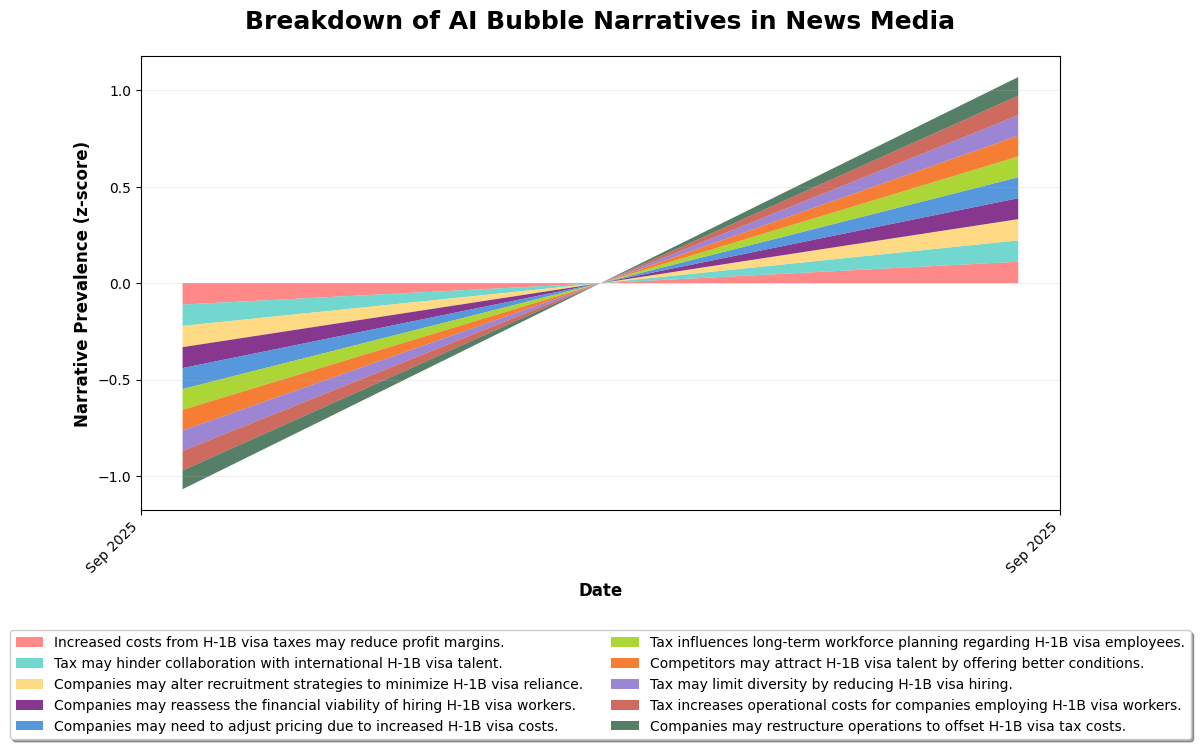

In [ ]:
# Create the narrative breakdown visualization for news 
fig2 = visualize_news_narrative_breakdown(news_df, interactive=False) #set interactive=True (or False) to enable (or disable) the interactive plot
fig2.show()

## Extract and Display Key Insights

Extract key insights from the narrative mining data and display them.

In [ ]:
# Extract insights from our narrative mining data
insights = extract_narrative_insights(news_df, transcripts_df, filings_df)

print("## AI Bubble Narrative Key Insights\n")
print(f"Peak month for news coverage: {insights['peak_news_month']}")
print(f"Peak month for earnings call mentions: {insights['peak_transcript_month']}")
print(f"Peak month for regulatory filing mentions: {insights['peak_filing_month']}")
print(f"\nDominant narrative in news: \"{insights['top_news_narrative']}\"")
print(f"Dominant narrative in earnings calls: \"{insights['top_transcript_narrative']}\"")
print(f"Dominant narrative in regulatory filings: \"{insights['top_filing_narrative']}\"")
print(f"\nTotal narrative mentions in news: {insights['total_news_mentions']}")
print(f"Total mentions in earnings calls: {insights['total_transcript_mentions']}")
print(f"Total mentions in regulatory filings: {insights['total_filing_mentions']}")
print(f"\nAverage lag between news coverage peaks and SEC filings: {insights['avg_lag_days']} days")

## AI Bubble Narrative Key Insights

Peak month for news coverage: September 2025
Peak month for earnings call mentions: September 2025
Peak month for regulatory filing mentions: March 2025

Dominant narrative in news: "A proposed tax impacting companies employing H-1B visa holders."
Dominant narrative in earnings calls: "Companies prefer focusing on long-term strategy"
Dominant narrative in regulatory filings: "Current AI investments may not generate predicted financial returns"

Total narrative mentions in news: 56503
Total mentions in earnings calls: 784
Total mentions in regulatory filings: 2645

Average lag between news coverage peaks and SEC filings: -182 days


## Export the Results

Export the data as Excel files for further analysis or to share with the team.

In [ ]:
try:
    # Create the Excel manager
    excel_manager = ExcelManager()

    # Define the dataframes and their sheet configurations
    df_args = [
        (news_df, "News Narratives", (0, 0)),
        (transcripts_df, "Earnings Call Narratives", (0, 0)),
        (filings_df, "SEC Filing Narratives", (0, 0)),
        (source_summary, "Summary", (1, 1))
    ]

    # Save the workbook
    combined_results_path = f"{output_dir}/ai_bubble_narrative_analysis.xlsx"
    excel_manager.save_workbook(df_args, combined_results_path)
    
    print(f"✅ Results exported to {combined_results_path}")

except Exception as e:
    print(f"Warning while exporting to excel: {e}")

✅ Results exported to output/ai_bubble_narrative_analysis.xlsx


## Conclusion

The Narrative Miners reveal important patterns in how the AI bubble narrative evolved across information sources:

**Timing and Intensity Variations:**

- News media shows major spikes in AI bubble concerns, often leading the narrative cycle with the highest peaks
- Earnings calls demonstrate cyclical attention to bubble concerns, with executives addressing topics most prominently during specific quarters
- SEC filings show the most volatile pattern with multiple significant spikes, suggesting ongoing regulatory concerns

**Narrative Progression:**

- Media coverage often leads the initial bubble narrative, potentially triggering corporate responses visible in earnings calls
- Corporate executives' discussions peak during specific periods but tend to diminish over time
- SEC filing mentions frequently show increased intensity throughout the analysis period, indicating persistent regulatory attention

**Cross-Source Intelligence:**

- Different sources provide complementary perspectives on the same underlying narrative
- Timing lags between sources reveal information flow patterns and decision-making hierarchies
- The intensity patterns help identify when narratives are gaining or losing momentum across different stakeholder groups

This analysis demonstrates how systematic narrative mining across multiple document types provides richer insights than analyzing any single source in isolation.